# Sprint 39 — INT8 intermédiaire : ablation & trade-off (S3911)

Synthèse PC (sans carte) des livrables Partie A :
- **Ablation** (`exp_S39_ablation/`, S3904) : *où est la perte F1 INT8 ?*
- **Sweep trade-off** (`exp_S39_quant_sweep/`, S3906) : *quel schéma équilibre RAM / latence-proxy / métrique ?*

Toutes les valeurs proviennent des JSON (aucune valeur en dur). Latences = proxy analytique
(`lat_proxy=true`) ; les mesures board réelles sont différées (Partie B, S3915).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

REPO = Path.cwd()
while not (REPO / 'experiments').exists() and REPO != REPO.parent:
    REPO = REPO.parent
ABLATION_DIR = REPO / 'experiments' / 'exp_S39_ablation'
SWEEP = json.loads((REPO / 'experiments' / 'exp_S39_quant_sweep' / 'summary.json').read_text())
FIG_DIR = REPO / 'docs' / 'figures' / 'sprint39_int8_intermediate'
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['cmapss', 'cwru', 'monitoring', 'pronostia', 'paderborn']
MODELS = ['ewc', 'mahalanobis', 'hdc', 'tinyol']
print('repo:', REPO)
print('models:', list(SWEEP), '| datasets:', list(SWEEP['ewc']))

repo: /home/leonard/Documents/ENAC/cl-embedded
models: ['ewc', 'mahalanobis', 'hdc', 'tinyol'] | datasets: ['cmapss', 'cwru', 'monitoring', 'pronostia', 'paderborn']


## 1. Ablation par facteur — où est la perte ?

F1 le long de l'`ABLATION_LADDER` (legacy_c → fix_acc32 → per_tensor_calib → per_channel_int8 → q15).
Le facteur dominant est la **calibration de l'échelle** (per_tensor_calib), pas l'accumulateur seul.

dominant factors: {'cmapss': 'per_tensor_calib', 'cwru': 'per_tensor_calib', 'monitoring': 'per_tensor_calib', 'paderborn': 'fix_acc32', 'pronostia': 'per_tensor_calib'}


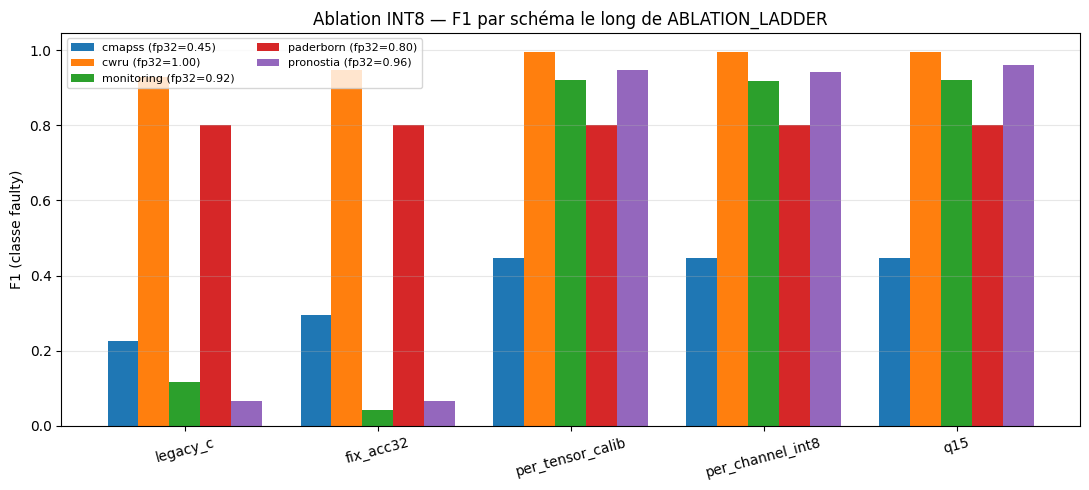

In [2]:
abl = {f.stem: json.loads(f.read_text()) for f in sorted(ABLATION_DIR.glob('*.json'))}
schemes = [s['scheme'] for s in next(iter(abl.values()))['ladder']]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(schemes))
w = 0.16
for i, (ds, d) in enumerate(abl.items()):
    f1 = [step['f1'] for step in d['ladder']]
    ax.bar(x + (i - len(abl) / 2) * w + w / 2, f1, w, label=f"{ds} (fp32={d['f1_fp32']:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(schemes, rotation=15)
ax.set_ylabel('F1 (classe faulty)')
ax.set_title('Ablation INT8 — F1 par schéma le long de ABLATION_LADDER')
ax.legend(fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'ablation_factors.png', dpi=150, bbox_inches='tight')
print('dominant factors:', {ds: d['dominant_scheme'] for ds, d in abl.items()})
plt.show()

## 2. Trade-off Pareto — RAM vs métrique (taille ∝ latence-proxy)

Un point par (modèle, dataset, schéma). X = ratio RAM vs FP32 (plus à droite = plus compact) ;
Y = métrique ; taille du marqueur ∝ latence-proxy relative. Le front de Pareto (compact **et** performant)
est annoté.

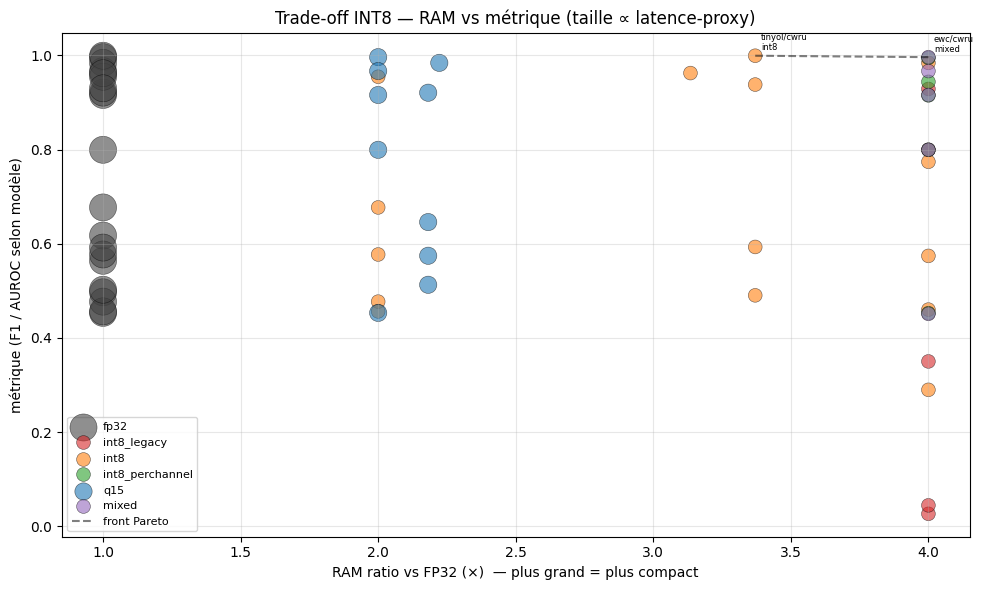

In [3]:
SCHEME_COLOR = {
    'fp32': '#444444', 'int8_legacy': '#d62728', 'int8': '#ff7f0e',
    'int8_perchannel': '#2ca02c', 'q15': '#1f77b4', 'mixed': '#9467bd',
}
pts = []
for model in MODELS:
    for ds in DATASETS:
        cell = SWEEP[model][ds]
        fp32_ram = cell['fp32']['ram_weights_bytes']
        for scheme, v in cell.items():
            m = v.get('metric')
            if m is None:
                continue
            ram_ratio = fp32_ram / v['ram_weights_bytes'] if v['ram_weights_bytes'] else 1.0
            pts.append((model, ds, scheme, ram_ratio, m, v.get('lat_proxy_rel', 1.0)))

fig, ax = plt.subplots(figsize=(10, 6))
for scheme in SCHEME_COLOR:
    sub = [p for p in pts if p[2] == scheme]
    if not sub:
        continue
    ax.scatter([p[3] for p in sub], [p[4] for p in sub],
               s=[80 + 300 * p[5] for p in sub], alpha=0.6,
               color=SCHEME_COLOR[scheme], edgecolors='k', linewidths=0.4, label=scheme)

# Front de Pareto (maximiser ram_ratio ET metric).
P = sorted(pts, key=lambda p: (-p[3], -p[4]))
front, best_m = [], -np.inf
for p in P:
    if p[4] > best_m:
        front.append(p)
        best_m = p[4]
front = sorted(front, key=lambda p: p[3])
ax.plot([p[3] for p in front], [p[4] for p in front], 'k--', alpha=0.5, label='front Pareto')
for p in front:
    ax.annotate(f"{p[0]}/{p[1]}\n{p[2]}", (p[3], p[4]), fontsize=6,
                textcoords='offset points', xytext=(4, 4))
ax.set_xlabel('RAM ratio vs FP32 (×)  — plus grand = plus compact')
ax.set_ylabel('métrique (F1 / AUROC selon modèle)')
ax.set_title('Trade-off INT8 — RAM vs métrique (taille ∝ latence-proxy)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / 'tradeoff_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Heatmaps 4×5 par schéma

Métrique (modèle × dataset) pour trois schémas. Un schéma absent pour un modèle est **gris (N/A)** :
- `legacy` : `int8_legacy` (EWC) — les autres modèles n'ont pas de variante "legacy" → N/A.
- `perchannel` : `int8_perchannel` (EWC) et `int8` (maha/hdc/tinyol).
- `q15` : `q15` (EWC, maha) — HDC/TinyOL sans Q15 → N/A.

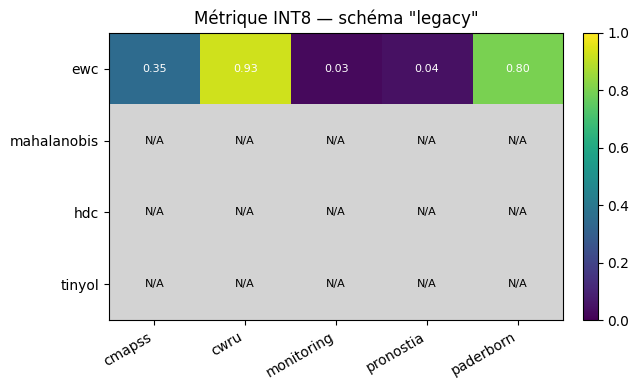

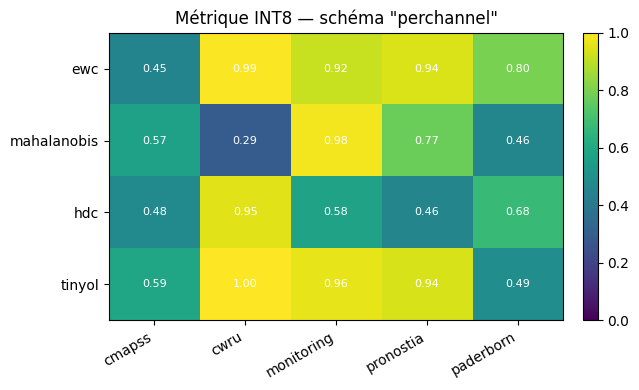

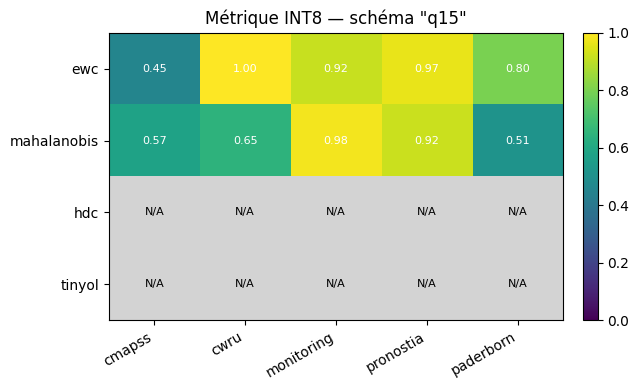

In [4]:
# Mapping schéma logique -> clé réelle par modèle (None => N/A gris).
SCHEME_MAP = {
    'legacy':      {'ewc': 'int8_legacy', 'mahalanobis': None, 'hdc': None, 'tinyol': None},
    'perchannel':  {'ewc': 'int8_perchannel', 'mahalanobis': 'int8', 'hdc': 'int8', 'tinyol': 'int8'},
    'q15':         {'ewc': 'q15', 'mahalanobis': 'q15', 'hdc': None, 'tinyol': None},
}

def matrix(scheme_logical):
    M = np.full((len(MODELS), len(DATASETS)), np.nan)
    for i, model in enumerate(MODELS):
        key = SCHEME_MAP[scheme_logical][model]
        if key is None:
            continue
        for j, ds in enumerate(DATASETS):
            v = SWEEP[model][ds].get(key)
            if v and v.get('metric') is not None:
                M[i, j] = v['metric']
    return M

cmap = plt.get_cmap('viridis').copy()
cmap.set_bad('lightgray')
for scheme in SCHEME_MAP:
    M = matrix(scheme)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    im = ax.imshow(np.ma.masked_invalid(M), cmap=cmap, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(DATASETS)))
    ax.set_xticklabels(DATASETS, rotation=30, ha='right')
    ax.set_yticks(range(len(MODELS)))
    ax.set_yticklabels(MODELS)
    ax.set_title(f'Métrique INT8 — schéma "{scheme}"')
    for i in range(len(MODELS)):
        for j in range(len(DATASETS)):
            txt = 'N/A' if np.isnan(M[i, j]) else f'{M[i, j]:.2f}'
            ax.text(j, i, txt, ha='center', va='center',
                    color='black' if np.isnan(M[i, j]) else 'white', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'heatmap_{scheme}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Récap recommandation par modèle

Schéma recommandé = celui qui préserve la métrique (Δ ≤ 0.02 vs FP32) au meilleur ratio RAM.
INT8 par-canal est visé par défaut (RAM ×4) ; Q15 est le repli (RAM ×2) si l'INT8 ne suffit pas.

In [5]:
# Ordre de préférence : compact d'abord (int8), Q15 en repli.
PREF = {
    'ewc': ['int8_perchannel', 'q15'],
    'mahalanobis': ['int8', 'q15'],
    'hdc': ['int8'],
    'tinyol': ['int8'],
}
TOL = 0.02
rows = []
for model in MODELS:
    reco, worst = None, 1.0
    for scheme in PREF[model]:
        deltas = []
        for ds in DATASETS:
            cell = SWEEP[model][ds]
            v, fp = cell.get(scheme), cell['fp32']['metric']
            if v and v.get('metric') is not None:
                deltas.append(v['metric'] - fp)
        if deltas and min(deltas) >= -TOL:
            reco = scheme
            worst = min(deltas)
            break
        if deltas:
            worst = min(deltas)
    rows.append((model, reco or f'{PREF[model][-1]} (Δ={worst:+.3f})', PREF[model][-1]))

print(f"{'modèle':<12}{'schéma recommandé (Δ métrique ≤ 0.02 vs fp32)':<45}")
print('-' * 57)
for model, reco, _ in rows:
    print(f'{model:<12}{reco:<45}')

modèle      schéma recommandé (Δ métrique ≤ 0.02 vs fp32)
---------------------------------------------------------
ewc         q15                                          
mahalanobis q15                                          
hdc         int8                                         
tinyol      int8                                         
